In [1]:
from hest import iter_hest

# Iterate through a subset of hest
for st in iter_hest('hest_data', id_list=['INT1']):

    # ST (adata):
    adata = st.adata
    print('\n* Scanpy adata:')
    print(adata)

    # WSI:
    wsi = st.wsi
    print('\n* WSI:')
    print(wsi)
    
    # Shapes:
    shapes = st.shapes
    print('\n* Shapes:')
    print(shapes)
    
    # Tissue segmentation
    tissue_contours = st.tissue_contours
    print('\n* Tissue contours:')
    print(tissue_contours)
    
    # Conversion to SpatialData
    sdata = st.to_spatial_data()
    print('\n* SpatialData conversion:')
    print(sdata)

C:\Users\Paramesh\HEST\src\hest\HESTData.py:1195: RuntimeWarning: CuCIM backend is not available; falling back to default WSI readers.
  CucimWarningSingleton.warn()



* Scanpy adata:
AnnData object with n_obs × n_vars = 1084 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

* WSI:
<width=19200, height=19968, backend=ImageWSI, mpp=0.4568931177233368, mag=20>

* Shapes:
[name: cellvit, coord-system: he, <not loaded>]

* Tissue contours:
  tissue_id                                           geometry
0         0  POLYGON ((4422 13907, 4422 13917, 4422 13927, ...
1         1  POLYGON ((2136 1807, 2136 1817, 2136 1827, 212..

C:\Users\Paramesh\anaconda3\envs\hest\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution



* SpatialData conversion:
SpatialData object
├── Images
│     ├── 'ST_downscaled_hires_image': SpatialImage[cyx] (3, 19968, 19200)
│     └── 'ST_downscaled_lowres_image': SpatialImage[cyx] (3, 1000, 962)
├── Shapes
│     ├── 'cellvit': GeoDataFrame shape: (37483, 3) (2D shapes)
│     ├── 'locations': GeoDataFrame shape: (1084, 2) (2D shapes)
│     └── 'tissue_contours': GeoDataFrame shape: (2, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1084, 36601)
with coordinate systems:
    ▸ 'ST_downscaled_hires', with elements:
        ST_downscaled_hires_image (Images), cellvit (Shapes), locations (Shapes), tissue_contours (Shapes)
    ▸ 'ST_downscaled_lowres', with elements:
        ST_downscaled_lowres_image (Images), cellvit (Shapes), locations (Shapes), tissue_contours (Shapes)


C:\Users\Paramesh\HEST\src\hest\HESTData.py:1589: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(adata, show=False, img_key="downscaled_fullres", color=[key], title=f"in_tissue spots", return_fig=True, **pl_kwargs)


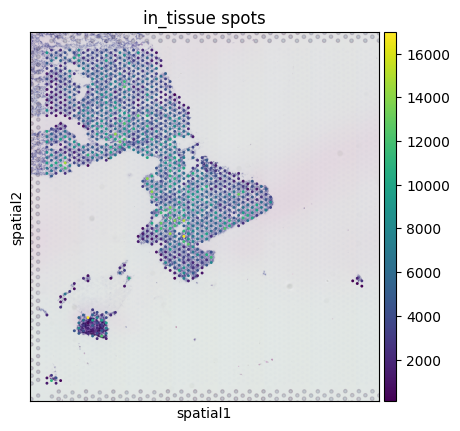

In [7]:
save_dir = '.'
st.save_spatial_plot(save_dir)

In [1]:
"""
HistoMoE  —  Small-Scale Prototype
"""

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import argparse, json, random, warnings
from pathlib import Path
from datetime import datetime
from types import SimpleNamespace

import numpy as np
import scipy.sparse as sp
from scipy.stats import pearsonr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
try:
    get_ipython()           
    _notebook = True
except NameError:
    _notebook = False
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Configurations
# ─────────────────────────────────────────────────────────────────────────────

CFG = dict(
    # ── data ─────────────────────────────────────────────────────────────────
    sample_dir   = "./hest_sample",
    n_hvg        = 50,
    patch_px     = 224,
    max_patches  = 400,

    # ── model (SMALL EXPERIMENTAL VERSION) ────────────────────────────────────────────────
    embed_dim    = 64,     
    meta_dim     = 16,    
    expert_hidden= 64,    
    num_shared   = 1,      
    num_fine     = 4,      
    topk         = 2,      
    dropout      = 0.1,

    # ── training ──────────────────────────────────────────────────────────────
    epochs       = 15,
    batch_size   = 64,
    lr           = 1e-3,
    val_frac     = 0.20,
    balance_factor = 0.02,

    # ── output ────────────────────────────────────────────────────────────────
    output_dir   = "./results",
    seed         = 42,
)


def get_cfg():
    import sys
    is_nb = any("kernel" in a or a.startswith("-f") for a in sys.argv[1:])
    if is_nb:
        return SimpleNamespace(**CFG)
    p = argparse.ArgumentParser(description="HistoMoE prototype")
    for k, v in CFG.items():
        if isinstance(v, bool):
            p.add_argument(f"--{k}", action="store_true", default=v)
        else:
            p.add_argument(f"--{k}", type=type(v), default=v)
    return p.parse_args()


# ──────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILITY
# ──────────────────────────────────────────────────────────────────────────────

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1 — LOAD ANNDATA & SELECT TOP-N HVGs
# ──────────────────────────────────────────────────────────────────────────────

def load_adata(sample_dir: Path, n_hvg: int = 50):
    
    import scanpy as sc

    sample_name = sample_dir.name
    h5_path = sample_dir.parent / "st" / f"{sample_name}.h5ad"

    if not h5_path.exists():
        raise FileNotFoundError(f"{h5_path} not found")

    print(f"[Data] Loading {h5_path.name}  …")
    adata = sc.read_h5ad(str(h5_path))
    print(f"  Raw shape: {adata.n_obs} spots × {adata.n_vars} genes")

    # ── keep in-tissue spots only ─────────────────────────────────────────
    if "in_tissue" in adata.obs.columns:
        adata = adata[adata.obs["in_tissue"] == 1].copy()
        print(f"  After in-tissue filter: {adata.n_obs} spots")

    # ── gene filter: ≥ 10% non-zero  (HEST-Benchmark protocol) ───────────
    X = adata.X
    if sp.issparse(X):
        nz_frac = np.asarray((X > 0).sum(axis=0)).flatten() / adata.n_obs
    else:
        nz_frac = (X > 0).mean(axis=0)
    adata = adata[:, nz_frac >= 0.10].copy()
    print(f"  After gene filter (≥10% non-zero): {adata.n_vars} genes")

    # ── normalise → log1p → HVG selection ────────────────────────────────
    a = adata.copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    sc.pp.highly_variable_genes(a, n_top_genes=n_hvg, flavor="seurat")

    hvg_mask   = a.var["highly_variable"].values
    gene_names = a.var_names[hvg_mask].tolist()

    X_hvg = a.X[:, hvg_mask]
    if sp.issparse(X_hvg):
        expr = X_hvg.toarray().astype(np.float32)
    else:
        expr = np.array(X_hvg, dtype=np.float32)

    print(f"  HVGs selected: {len(gene_names)}")
    print(f"  Top 5: {gene_names[:5]}")

    # ── spatial coords  obsm['spatial'] = (N,2)  col_px, row_px ──────────
    if "spatial" in adata.obsm:
        spot_coords = np.array(adata.obsm["spatial"], dtype=np.float32)
    else:
        spot_coords = np.column_stack([
            adata.obs["pxl_col_in_fullres"].values,
            adata.obs["pxl_row_in_fullres"].values,
        ]).astype(np.float32)

    return expr, gene_names, spot_coords, adata


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2 — EXTRACT 224×224 PATCHES FROM THE WSI
# ──────────────────────────────────────────────────────────────────────────────

def find_wsi(sample_dir: Path) -> str:
    sample_name = sample_dir.name
    wsi_path = sample_dir.parent / "wsis" / f"{sample_name}.tif"
    return str(wsi_path) if wsi_path.exists() else None


def extract_patches(wsi_path: str, spot_coords: np.ndarray,
                    patch_px: int = 224, max_patches: int = 400,
                    seed: int = 42):
    
    rng  = np.random.default_rng(seed)
    n    = len(spot_coords)
    half = patch_px // 2

    if n > max_patches:
        sel = np.sort(rng.choice(n, max_patches, replace=False))
    else:
        sel = np.arange(n)

    # ── try OpenSlide first, then PIL ─────────────────────────────────────
    reader = None
    if wsi_path:
        try:
            import openslide
            reader = openslide.OpenSlide(wsi_path)
            mode   = "openslide"
        except Exception:
            try:
                from PIL import Image as PILImage
                reader = PILImage.open(wsi_path)
                mode   = "pil"
            except Exception:
                reader = None

    patches = []
    skipped = 0
    for idx in sel:
        x0 = int(spot_coords[idx, 0]) - half
        y0 = int(spot_coords[idx, 1]) - half
        try:
            if reader and mode == "openslide":
                region = reader.read_region((x0, y0), 0, (patch_px, patch_px))
                img    = np.array(region.convert("RGB"))
            elif reader and mode == "pil":
                region = reader.crop((x0, y0, x0 + patch_px, y0 + patch_px))
                img    = np.array(region.convert("RGB"))
            else:
                raise ValueError("no reader")
        except Exception:
            skipped += 1
            img = np.full((patch_px, patch_px, 3), 230, dtype=np.uint8)

        # pad boundary patches
        if img.shape[:2] != (patch_px, patch_px):
            pad = np.full((patch_px, patch_px, 3), 230, dtype=np.uint8)
            h, w = img.shape[:2]
            pad[:h, :w] = img
            img = pad

        patches.append(img)

    if reader and mode == "openslide":
        reader.close()

    if skipped:
        print(f"  [WSI] {skipped}/{len(sel)} patches substituted (boundary/error)")

    arr = np.stack(patches, axis=0)           # (n, H, W, 3)
    arr = arr.transpose(0, 3, 1, 2)           # (n, 3, H, W)  NCHW
    return arr, sel


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3 — METADATA ENCODING
# ──────────────────────────────────────────────────────────────────────────────

META_DIM = 4   # array_row_norm, array_col_norm, pxl_row_norm, pxl_col_norm

def build_spot_metadata(adata, selected_idx: np.ndarray) -> np.ndarray:
    """
    Build a (n, 4) float32 array of normalised spatial metadata per spot.
    """
    obs = adata.obs

    def _norm(col):
        vals = obs[col].values.astype(np.float32)
        vmin, vmax = vals.min(), vals.max()
        return (vals - vmin) / (vmax - vmin + 1e-8)

    arr_row  = _norm("array_row")
    arr_col  = _norm("array_col")
    pxl_row  = _norm("pxl_row_in_fullres")
    pxl_col  = _norm("pxl_col_in_fullres")

    meta = np.stack([arr_row, arr_col, pxl_row, pxl_col], axis=1)  # (N, 4)
    return meta[selected_idx].astype(np.float32)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 4 — PYTORCH DATASET
# ──────────────────────────────────────────────────────────────────────────────

class HESTSpotDataset(Dataset):
    def __init__(self, patches, metadata, expression):
        # patches:    (N, 3, 224, 224) uint8  →  float [0,1]
        # metadata:   (N, 4)  float32
        # expression: (N, 50) float32
        self.patches = torch.from_numpy(patches).float().div(255.0)
        self.meta    = torch.from_numpy(metadata).float()
        self.expr    = torch.from_numpy(expression).float()

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, i):
        return self.patches[i], self.meta[i], self.expr[i]


# ──────────────────────────────────────────────────────────────────────────────
# STEP 5 — VISION ENCODER  (frozen ResNet50, ImageNet pretrained)
# ──────────────────────────────────────────────────────────────────────────────

class VisionEncoder(nn.Module):
    """
    Frozen ResNet50 backbone  →  linear projection  →  embed_dim.
    Following HEST-Benchmark: pretrained features + dimensionality reduction.
    """
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        import torchvision.models as tv
        base    = tv.resnet50(weights=tv.ResNet50_Weights.IMAGENET1K_V2)
        # remove the classification head — keep the global average pool
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.proj = nn.Linear(2048, embed_dim, bias=False)

        # ImageNet normalisation constants
        self.register_buffer("mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        f = self.backbone(x)
        return f.view(f.size(0), -1)            # (B, 2048)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(self.encode(x))        # backbone always frozen


# ──────────────────────────────────────────────────────────────────────────────
# STEP 6 — METADATA ENCODER
# ──────────────────────────────────────────────────────────────────────────────

class MetadataEncoder(nn.Module):
    
    def __init__(self, in_dim: int = META_DIM, hidden: int = 32,
                 out_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 7 — EXPERT MLP
# ──────────────────────────────────────────────────────────────────────────────

class ExpertMLP(nn.Module):
    """
    Single expert network.
    3-layer MLP with GELU activation, LayerNorm, Dropout.
    Input: fused embedding (embed_dim + meta_dim).
    Output: predicted log1p expression for n_hvg genes.
    """
    def __init__(self, in_dim: int, hidden: int, out_dim: int,
                 dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.LayerNorm(hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, out_dim),
        )

    def forward(self, x):
        return self.net(x)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 8 — GATING NETWORK  (top-k + aux-loss-free load balancing)
# ──────────────────────────────────────────────────────────────────────────────

class GatingNetwork(nn.Module):
    
    def __init__(self, in_dim: int, num_experts: int, topk: int = 2,
                 balance_factor: float = 0.02):
        super().__init__()
        self.num_experts     = num_experts
        self.topk            = topk
        self.balance_factor  = balance_factor

        self.gate = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.GELU(),
            nn.Linear(in_dim // 2, num_experts),
        )
        # Per-expert bias — not a Parameter, updated by update_bias()
        self.register_buffer("bias", torch.zeros(num_experts))

    def forward(self, x):
        
        logits   = self.gate(x)                              # (B, E)
        adjusted = logits + self.bias.unsqueeze(0)           # add per-expert bias
        vals, idx = torch.topk(adjusted, self.topk, dim=-1)  # (B, topk)
        weights  = F.softmax(vals, dim=-1)                   # (B, topk)
        return weights, idx, logits

    @torch.no_grad()
    def update_bias(self, expert_counts: torch.Tensor):
        
        target       = expert_counts.float().sum() / self.num_experts
        delta        = self.balance_factor * (target - expert_counts.float())
        self.bias   += delta


# ──────────────────────────────────────────────────────────────────────────────
# STEP 9 — HISTOMOE  (full model)
# ──────────────────────────────────────────────────────────────────────────────

class HistoMoE(nn.Module):
    
    def __init__(self, embed_dim, meta_dim, expert_hidden,
                 n_hvg, num_shared, num_fine, topk,
                 dropout, balance_factor):
        super().__init__()
        fused_dim = embed_dim + meta_dim

        self.meta_encoder = MetadataEncoder(
            in_dim=META_DIM, hidden=32, out_dim=meta_dim)

        self.shared_experts = nn.ModuleList([
            ExpertMLP(fused_dim, expert_hidden, n_hvg, dropout)
            for _ in range(num_shared)
        ])

        self.fine_experts = nn.ModuleList([
            ExpertMLP(fused_dim, expert_hidden, n_hvg, dropout)
            for _ in range(num_fine)
        ])

        self.gate = GatingNetwork(
            in_dim=fused_dim,
            num_experts=num_fine,
            topk=topk,
            balance_factor=balance_factor,
        )

        self.num_fine = num_fine
        self.topk     = topk
        self.n_hvg    = n_hvg

    def forward(self, patch_embed, meta_raw):
        
        B = patch_embed.size(0)

        meta_embed = self.meta_encoder(meta_raw)                  # (B, meta_dim)
        fused      = torch.cat([patch_embed, meta_embed], dim=-1) # (B, fused_dim)

        # ── shared experts  (always active, summed) ───────────────────────
        shared_out = sum(e(fused) for e in self.shared_experts)   # (B, n_hvg)

        # ── gating + fine-grained experts ─────────────────────────────────
        weights, indices, logits = self.gate(fused)               # (B,k) each

        fine_out      = torch.zeros(B, self.n_hvg, device=patch_embed.device)
        expert_counts = torch.zeros(self.num_fine, device=patch_embed.device)

        for k in range(self.topk):
            exp_idx = indices[:, k]   # (B,) which expert each spot uses at slot k
            w       = weights[:, k]   # (B,) routing weight for that expert

            for e in range(self.num_fine):
                mask = (exp_idx == e)
                if not mask.any():
                    continue
                expert_counts[e] += mask.sum()
                out_e = self.fine_experts[e](fused[mask])         # (n_e, n_hvg)
                fine_out[mask] += w[mask].unsqueeze(-1) * out_e

        pred = shared_out + fine_out                              # (B, n_hvg)
        return pred, weights, indices, expert_counts


# ──────────────────────────────────────────────────────────────────────────────
# STEP 10 — BASELINE  (single MLP, no routing)
# ──────────────────────────────────────────────────────────────────────────────

class BaselineMLP(nn.Module):
    """
    Simple global MLP — no expert specialisation.
    Same parameter budget as one HistoMoE expert for fair comparison.
    """
    def __init__(self, embed_dim, meta_dim, expert_hidden, n_hvg, dropout):
        super().__init__()
        in_dim = embed_dim + meta_dim
        self.meta_encoder = MetadataEncoder(
            in_dim=META_DIM, hidden=32, out_dim=meta_dim)
        self.net = nn.Sequential(
            nn.Linear(in_dim, expert_hidden),
            nn.LayerNorm(expert_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(expert_hidden, expert_hidden // 2),
            nn.LayerNorm(expert_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(expert_hidden // 2, n_hvg),
        )

    def forward(self, patch_embed, meta_raw):
        meta_embed = self.meta_encoder(meta_raw)
        x          = torch.cat([patch_embed, meta_embed], dim=-1)
        pred       = self.net(x)
        return pred, None, None, None


# ──────────────────────────────────────────────────────────────────────────────
# STEP 11 — EVALUATION METRIC  (HEST-1k paper: mean Pearson CC over HVGs)
# ──────────────────────────────────────────────────────────────────────────────

def mean_pcc(y_pred: np.ndarray, y_true: np.ndarray):
    
    per_gene = np.array([
        pearsonr(y_pred[:, g], y_true[:, g])[0]
        for g in range(y_pred.shape[1])
    ])
    per_gene = np.nan_to_num(per_gene, nan=0.0)  # NaN → 0 for constant preds
    return float(np.mean(per_gene)), per_gene


# ──────────────────────────────────────────────────────────────────────────────
# STEP 12 — TRAIN / EVAL LOOPS
# ──────────────────────────────────────────────────────────────────────────────

def train_epoch(model, vision_enc, loader, opt, device, is_moe):
    model.train()
    vision_enc.eval()   # encoder always frozen
    total_loss    = 0.0
    batch_counts  = []

    for patches, meta, expr in loader:
        patches = patches.to(device)
        meta    = meta.to(device)
        expr    = expr.to(device)

        with torch.no_grad():
            patch_emb = vision_enc(patches)   # frozen

        opt.zero_grad()
        pred, _, _, counts = model(patch_emb, meta)

        loss = F.mse_loss(pred, expr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()

        total_loss += loss.item() * len(patches)

        if is_moe and counts is not None:
            model.gate.update_bias(counts.detach())
            batch_counts.append(counts.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)

    # Aggregate expert usage over the epoch
    if batch_counts:
        epoch_counts = torch.stack(batch_counts).sum(0)
        epoch_counts = epoch_counts / epoch_counts.sum().clamp(min=1)
    else:
        epoch_counts = None

    return avg_loss, epoch_counts


@torch.no_grad()
def eval_model(model, vision_enc, loader, device, is_moe):
    model.eval()
    vision_enc.eval()
    all_pred, all_true = [], []
    all_weights, all_indices = [], []

    for patches, meta, expr in loader:
        patches = patches.to(device)
        meta    = meta.to(device)

        patch_emb = vision_enc(patches)
        pred, weights, indices, _ = model(patch_emb, meta)

        all_pred.append(pred.cpu().numpy())
        all_true.append(expr.numpy())

        if is_moe and weights is not None:
            all_weights.append(weights.cpu().numpy())
            all_indices.append(indices.cpu().numpy())

    y_pred = np.concatenate(all_pred, axis=0)
    y_true = np.concatenate(all_true, axis=0)
    pcc_mean, pcc_per_gene = mean_pcc(y_pred, y_true)

    routing = None
    if all_weights:
        routing = {
            "weights": np.concatenate(all_weights, axis=0),   # (N, topk)
            "indices": np.concatenate(all_indices, axis=0),   # (N, topk)
        }
    return pcc_mean, pcc_per_gene, y_pred, y_true, routing


# ──────────────────────────────────────────────────────────────────────────────
# STEP 13 — SPATIAL SPLIT  (by Visium array position, not random)
# ──────────────────────────────────────────────────────────────────────────────

def spatial_train_val_split(adata, selected_idx, val_frac=0.20, seed=42):
    
    cols = adata.obs["array_col"].values[selected_idx]
    col_threshold = np.quantile(cols, 1.0 - val_frac)

    val_mask   = cols >= col_threshold
    train_mask = ~val_mask

    train_idx = np.where(train_mask)[0]
    val_idx   = np.where(val_mask)[0]

    print(f"[Split] Spatial split: "
          f"train={len(train_idx)} spots  val={len(val_idx)} spots "
          f"(col ≥ {col_threshold:.0f} → val)")
    return train_idx, val_idx


# ──────────────────────────────────────────────────────────────────────────────
# STEP 14 — VISUALISATIONS
# ──────────────────────────────────────────────────────────────────────────────

def plot_all(results, gene_names, spot_coords_val, adata, selected_idx,
             val_idx, cfg, out_dir):
    
    out_dir.mkdir(parents=True, exist_ok=True)
    moe = results["HistoMoE"]
    bl  = results.get("Baseline")
    C   = cfg.num_fine

    # ── Plot 1: Training & validation curves ─────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(moe["train_losses"], label="HistoMoE",  color="#2E75B6", lw=2)
    if bl:
        ax1.plot(bl["train_losses"], label="Baseline", color="#ED7D31",
                 lw=2, linestyle="--")
    ax1.set_title("Training Loss (MSE)", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(moe["val_pccs"], label="HistoMoE",  color="#2E75B6", lw=2)
    if bl:
        ax2.plot(bl["val_pccs"],   label="Baseline", color="#ED7D31",
                 lw=2, linestyle="--")
    ax2.set_title("Validation Mean PCC  (HEST-1k metric)", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Mean Pearson CC")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "01_training_curves.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("[Plot] 01_training_curves.png")

    # ── Plot 2: Expert usage distribution ────────────────────────────────
    if moe.get("routing"):
        rt    = moe["routing"]
        flat  = rt["indices"].flatten()
        cnts  = np.bincount(flat, minlength=C)
        pcts  = 100.0 * cnts / cnts.sum()

        fig, ax = plt.subplots(figsize=(7, 4))
        colors = ["#2E75B6" if p > 1.0 else "#D9534F" for p in pcts]
        bars = ax.bar(
            [f"Expert {i}" for i in range(C)], pcts,
            color=colors, edgecolor="white", linewidth=1.2, width=0.55
        )
        for bar, p in zip(bars, pcts):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"{p:.1f}%", ha="center", fontsize=10, fontweight="bold")

        ax.axhline(100/C, color="gray", linestyle="--", lw=1.5,
                   label=f"Uniform ({100/C:.1f}%)")
        for i, p in enumerate(pcts):
            if p < 1.0:
                ax.text(i, 2, "DEAD\n↑ bias correcting",
                        ha="center", color="#D9534F", fontsize=8,
                        fontweight="bold")
        ax.set_title("Fine-Grained Expert Usage (Validation Set)",
                     fontweight="bold")
        ax.set_ylabel("Usage (%)"); ax.legend(); ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0, max(pcts) * 1.3)
        plt.tight_layout()
        fig.savefig(out_dir / "02_expert_usage.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("[Plot] 02_expert_usage.png")

    # ── Plot 3: Per-gene PCC bar chart ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    x  = np.arange(len(gene_names))
    bw = 0.38

    if bl:
        ax.bar(x - bw/2, moe["pcc_per_gene"], bw,
               label="HistoMoE", color="#2E75B6", alpha=0.85)
        ax.bar(x + bw/2, bl["pcc_per_gene"],  bw,
               label="Baseline",  color="#ED7D31", alpha=0.85)
    else:
        ax.bar(x, moe["pcc_per_gene"], color="#2E75B6", alpha=0.85,
               label="HistoMoE")

    ax.set_xticks(x)
    ax.set_xticklabels(gene_names, rotation=45, ha="right", fontsize=7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Per-Gene Pearson Correlation  (top-{cfg.n_hvg} HVGs)",
                 fontweight="bold")
    ax.set_ylabel("Pearson CC"); ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_dir / "03_per_gene_pcc.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("[Plot] 03_per_gene_pcc.png")

    # ── Plot 4: Routing weight heatmap + co-activation matrix ────────────
    if moe.get("routing"):
        rt = moe["routing"]
        fig, (ax_w, ax_c) = plt.subplots(1, 2, figsize=(12, 4))

        # Average weight received per expert
        avg_w = np.zeros(C)
        for k in range(cfg.topk):
            for e in range(C):
                mask = rt["indices"][:, k] == e
                if mask.any():
                    avg_w[e] += rt["weights"][mask, k].mean()
        ax_w.bar(range(C), avg_w, color="#2E75B6", edgecolor="white")
        ax_w.set_title("Average Routing Weight per Expert",
                       fontweight="bold")
        ax_w.set_xlabel("Expert"); ax_w.set_ylabel("Avg weight")
        ax_w.set_xticks(range(C)); ax_w.grid(axis="y", alpha=0.3)

        # Co-activation matrix (which pairs of experts are selected together)
        coact = np.zeros((C, C))
        if cfg.topk >= 2:
            for i, j in zip(rt["indices"][:, 0], rt["indices"][:, 1]):
                coact[i, j] += 1
                coact[j, i] += 1
        im = ax_c.imshow(coact, cmap="Blues")
        ax_c.set_title("Expert Co-activation  (top-2 routing)",
                       fontweight="bold")
        ax_c.set_xlabel("Expert j"); ax_c.set_ylabel("Expert i")
        ax_c.set_xticks(range(C)); ax_c.set_yticks(range(C))
        for i in range(C):
            for j in range(C):
                ax_c.text(j, i, int(coact[i, j]),
                          ha="center", va="center", fontsize=9,
                          color="white" if coact[i, j] > coact.max()*0.6 else "black")
        plt.colorbar(im, ax=ax_c)
        plt.tight_layout()
        fig.savefig(out_dir / "04_routing_analysis.png", dpi=150,
                    bbox_inches="tight")
        plt.close()
        print("[Plot] 04_routing_analysis.png")

    # ── Plot 5: Spatial expert assignment map ────────────────────────────
    if moe.get("routing") and spot_coords_val is not None:
        rt          = moe["routing"]
        # Dominant expert = the expert with the highest routing weight per spot
        dom_expert  = rt["indices"][:, 0]          # top-1 expert index (N,)
        coords_v    = spot_coords_val               # (N_val, 2)  col_px, row_px

        fig, ax = plt.subplots(figsize=(7, 7))
        cmap = plt.cm.get_cmap("tab10", C)
        for e in range(C):
            mask = dom_expert == e
            if mask.any():
                ax.scatter(
                    coords_v[mask, 0], coords_v[mask, 1],
                    s=8, alpha=0.7,
                    color=cmap(e), label=f"Expert {e}"
                )
        ax.set_title("Spatial Distribution of Expert Assignments\n"
                     "(validation spots, dominant expert)",
                     fontweight="bold")
        ax.set_xlabel("Pixel col (x)"); ax.set_ylabel("Pixel row (y)")
        ax.invert_yaxis()   # image coordinates: row 0 is at the top
        ax.legend(markerscale=3, fontsize=9)
        ax.set_aspect("equal")
        plt.tight_layout()
        fig.savefig(out_dir / "05_spatial_expert_map.png", dpi=150,
                    bbox_inches="tight")
        plt.close()
        print("[Plot] 05_spatial_expert_map.png")

    # ── Plot 6: Summary PCC bar + expert load-balance heatmap ────────────
    fig = plt.figure(figsize=(12, 4))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])
    ax_bar = fig.add_subplot(gs[0])
    ax_lb  = fig.add_subplot(gs[1])

    # Bar: final val PCC comparison
    names  = list(results.keys())
    pccs   = [results[n]["best_pcc"] for n in names]
    colors = ["#2E75B6" if "HistoMoE" in n else "#ED7D31" for n in names]
    bars   = ax_bar.bar(names, pccs, color=colors, edgecolor="white",
                        linewidth=1.5, width=0.5)
    for bar, v in zip(bars, pccs):
        ax_bar.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f"{v:.4f}", ha="center", fontweight="bold", fontsize=11)
    ax_bar.set_title("Best Validation Mean PCC", fontweight="bold")
    ax_bar.set_ylabel("Mean Pearson CC")
    ax_bar.set_ylim(0, max(pccs) * 1.25)
    ax_bar.grid(axis="y", alpha=0.3)

    # Load-balance heatmap: expert usage fraction per training epoch
    # (stored as per-epoch expert load fractions)
    lb_history = moe.get("lb_history")  # list of (num_fine,) arrays
    if lb_history and len(lb_history) > 1:
        lb_mat = np.stack(lb_history, axis=0).T   # (num_fine, epochs)
        im = ax_lb.imshow(lb_mat, aspect="auto", cmap="YlOrRd",
                          vmin=0, vmax=1)
        ax_lb.set_title("Expert Load Fraction per Epoch  (load balancing)",
                        fontweight="bold")
        ax_lb.set_xlabel("Epoch"); ax_lb.set_ylabel("Expert index")
        ax_lb.set_yticks(range(C))
        plt.colorbar(im, ax=ax_lb, label="Fraction of routed patches")
    else:
        ax_lb.text(0.5, 0.5, "Load balance history\nnot available",
                   ha="center", va="center", transform=ax_lb.transAxes)

    plt.tight_layout()
    fig.savefig(out_dir / "06_summary.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("[Plot] 06_summary.png")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 15 — MAIN EXPERIMENT
# ──────────────────────────────────────────────────────────────────────────────

def run(cfg):
    set_seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    out_dir = Path(cfg.output_dir) / datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*58}")
    print("  HistoMoE  —  Small-Scale Prototype")
    print(f"  Sample  : {cfg.sample_dir}")
    print(f"  Device  : {device}")
    print(f"  Experts : {cfg.num_shared} shared + {cfg.num_fine} fine-grained "
          f"(top-{cfg.topk})")
    print(f"  HVGs    : {cfg.n_hvg}   Epochs: {cfg.epochs}")
    print(f"{'='*58}\n")

    sample_dir = Path(cfg.sample_dir)

    # ── 1. Load data ──────────────────────────────────────────────────────
    expr, gene_names, spot_coords, adata = load_adata(sample_dir, cfg.n_hvg)

    # ── 2. Extract patches ────────────────────────────────────────────────
    wsi_path = find_wsi(sample_dir)
    if wsi_path:
        print(f"\n[WSI] Found: {Path(wsi_path).name}")
    else:
        print("\n[WSI] Not found — using white placeholder patches.")

    patches, sel_idx = extract_patches(
        wsi_path, spot_coords,
        patch_px=cfg.patch_px,
        max_patches=cfg.max_patches,
        seed=cfg.seed,
    )
    expr_sel   = expr[sel_idx]                    # align expr to selected spots
    coords_sel = spot_coords[sel_idx]             # align coords

    print(f"\n[Data] Patches : {patches.shape}")
    print(f"[Data] Expr    : {expr_sel.shape}")

    # ── 3. Build metadata ─────────────────────────────────────────────────
    meta = build_spot_metadata(adata, sel_idx)    # (n, 4) spatial features

    # ── 4. Spatial train/val split ────────────────────────────────────────
    tr_idx, vl_idx = spatial_train_val_split(
        adata, sel_idx, val_frac=cfg.val_frac, seed=cfg.seed)

    train_ds = HESTSpotDataset(
        patches[tr_idx], meta[tr_idx], expr_sel[tr_idx])
    val_ds   = HESTSpotDataset(
        patches[vl_idx], meta[vl_idx], expr_sel[vl_idx])

    train_dl = DataLoader(train_ds, batch_size=cfg.batch_size,
                          shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size,
                          shuffle=False, num_workers=0)

    print(f"[Split] Train: {len(train_ds)}  Val: {len(val_ds)}")

    coords_val = coords_sel[vl_idx]               # pixel coords of val spots

    # ── 5. Build vision encoder ───────────────────────────────────────────
    vision_enc = VisionEncoder(embed_dim=cfg.embed_dim).to(device)
    print(f"\n[Model] ResNet50 backbone frozen. Projection: 2048 → {cfg.embed_dim}")

    # ── 6. Train models ───────────────────────────────────────────────────
    results = {}

    model_specs = {
        "HistoMoE": (
            HistoMoE(
                embed_dim=cfg.embed_dim,
                meta_dim=cfg.meta_dim,
                expert_hidden=cfg.expert_hidden,
                n_hvg=cfg.n_hvg,
                num_shared=cfg.num_shared,
                num_fine=cfg.num_fine,
                topk=cfg.topk,
                dropout=cfg.dropout,
                balance_factor=cfg.balance_factor,
            ),
            True,
        ),
        "Baseline": (
            BaselineMLP(
                embed_dim=cfg.embed_dim,
                meta_dim=cfg.meta_dim,
                expert_hidden=cfg.expert_hidden,
                n_hvg=cfg.n_hvg,
                dropout=cfg.dropout,
            ),
            False,
        ),
    }

    for name, (model, is_moe) in model_specs.items():
        model = model.to(device)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"\n{'─'*50}")
        print(f"  Training: {name}   ({n_params:,} trainable params)")
        print(f"{'─'*50}")

        opt   = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                                   weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=cfg.epochs, eta_min=1e-5)

        train_losses = []
        val_pccs     = []
        lb_history   = []
        best_pcc     = -1.0
        best_state   = None
        best_routing = None
        best_per_gene= None

        for epoch in range(1, cfg.epochs + 1):
            tr_loss, epoch_counts = train_epoch(
                model, vision_enc, train_dl, opt, device, is_moe)
            sched.step()

            val_pcc, pcc_pg, y_pred, y_true, routing = eval_model(
                model, vision_enc, val_dl, device, is_moe)

            train_losses.append(tr_loss)
            val_pccs.append(val_pcc)
            if epoch_counts is not None:
                lb_history.append(epoch_counts.numpy().tolist())

            if val_pcc > best_pcc:
                best_pcc     = val_pcc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}
                best_routing = routing
                best_per_gene= pcc_pg

            star = "★" if val_pcc == best_pcc else " "
            if epoch % 5 == 0 or epoch == 1:
                print(f"  Epoch {epoch:3d}/{cfg.epochs}  "
                      f"loss={tr_loss:.5f}  val_PCC={val_pcc:.4f}  {star}")

        print(f"\n  Best val PCC: {best_pcc:.4f}")

        results[name] = {
            "train_losses" : train_losses,
            "val_pccs"     : val_pccs,
            "best_pcc"     : best_pcc,
            "pcc_per_gene" : best_per_gene,
            "routing"      : best_routing,
            "lb_history"   : lb_history,
        }

        torch.save(best_state,
                   out_dir / f"{name.lower()}_best.pt")

    # ── 7. Print summary ──────────────────────────────────────────────────
    print(f"\n{'='*58}")
    print("  RESULTS SUMMARY")
    print(f"  Sample: {sample_dir.name}   HVGs: {cfg.n_hvg}")
    print(f"{'='*58}")
    for name, res in results.items():
        print(f"  {name:<12}  Best val PCC: {res['best_pcc']:.4f}")

    moe_res = results["HistoMoE"]
    if moe_res.get("routing"):
        rt    = moe_res["routing"]
        flat  = rt["indices"].flatten()
        cnts  = np.bincount(flat, minlength=cfg.num_fine)
        total = cnts.sum()
        print(f"\n  Expert usage (validation, dominant expert):")
        for i, c in enumerate(cnts):
            bar  = "█" * int(30 * c / max(total, 1))
            dead = "  ← dead (bias correcting)" if c == 0 else ""
            print(f"    Expert {i}: {100*c/total:5.1f}%  {bar}{dead}")

    # ── 8. Plots ──────────────────────────────────────────────────────────
    plot_all(results, gene_names, coords_val, adata, sel_idx,
             vl_idx, cfg, out_dir)

    # ── 9. Save JSON log ──────────────────────────────────────────────────
    log = {
        "sample"  : str(sample_dir),
        "timestamp": datetime.now().isoformat(),
        "config"  : vars(cfg),
        "results" : {
            n: {
                "best_val_pcc"  : float(r["best_pcc"]),
                "final_val_pcc" : float(r["val_pccs"][-1]),
                "train_losses"  : [float(x) for x in r["train_losses"]],
                "val_pccs"      : [float(x) for x in r["val_pccs"]],
            }
            for n, r in results.items()
        },
    }
    with open(out_dir / "log.json", "w") as f:
        json.dump(log, f, indent=2)

    print(f"\n[Done] All outputs saved to: {out_dir}\n")
    return results


# ──────────────────────────────────────────────────────────────────────────────
# ENTRY POINTS
# ──────────────────────────────────────────────────────────────────────────────
#
#  Jupyter / Colab:
#      Edit CFG dict at the top, then:
#          run(get_cfg())
#
#  Terminal:
#      python histomoe_prototype.py --sample_dir path/to/INT1 --epochs 40

# if __name__ == "__main__":
#     run(get_cfg())

In [2]:
CFG["sample_dir"] = "hest_data/INT1"
run(get_cfg())


  HistoMoE  —  Small-Scale Prototype
  Sample  : hest_data/INT1
  Device  : cpu
  Experts : 1 shared + 4 fine-grained (top-2)
  HVGs    : 50   Epochs: 15

[Data] Loading INT1.h5ad  …
  Raw shape: 1084 spots × 36601 genes
  After in-tissue filter: 1084 spots
  After gene filter (≥10% non-zero): 6362 genes
  HVGs selected: 50
  Top 5: ['DDR2', 'ANGEL2', 'ITGB1BP1', 'ANTXR1', 'CXCR4']

[WSI] Found: INT1.tif

[Data] Patches : (400, 3, 224, 224)
[Data] Expr    : (400, 50)
[Split] Spatial split: train=320 spots  val=80 spots (col ≥ 110 → val)
[Split] Train: 320  Val: 80

[Model] ResNet50 backbone frozen. Projection: 2048 → 64

──────────────────────────────────────────────────
  Training: HistoMoE   (49,718 trainable params)
──────────────────────────────────────────────────
  Epoch   1/15  loss=0.48887  val_PCC=-0.0187  ★
  Epoch   5/15  loss=0.29206  val_PCC=-0.0140   
  Epoch  10/15  loss=0.27497  val_PCC=-0.0168   
  Epoch  15/15  loss=0.27060  val_PCC=-0.0114  ★

  Best val PCC: -0.011

{'HistoMoE': {'train_losses': [0.4888681173324585,
   0.37891753315925597,
   0.330438506603241,
   0.3006818056106567,
   0.2920555055141449,
   0.2827573388814926,
   0.27879955172538756,
   0.27565009891986847,
   0.2762404143810272,
   0.2749741107225418,
   0.27265853583812716,
   0.27076089978218076,
   0.2712137192487717,
   0.2728955984115601,
   0.27060321569442747],
  'val_pccs': [-0.018690163269639015,
   -0.013223293237388134,
   -0.016750475391745567,
   -0.01587718166410923,
   -0.013987427577376366,
   -0.017145074903964996,
   -0.012607795186340809,
   -0.016948478296399117,
   -0.011818774044513702,
   -0.01683300919830799,
   -0.011533427983522415,
   -0.016700176522135735,
   -0.011373276822268963,
   -0.01666286028921604,
   -0.011350546963512897],
  'best_pcc': -0.011350546963512897,
  'pcc_per_gene': array([-0.04329536,  0.07764731, -0.10275712, -0.1642823 , -0.08086152,
          0.03419359, -0.19169377,  0.01508849, -0.01085393,  0.0808397 ,
         -0.00368854